In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hr-data/PerformanceRating.csv
/kaggle/input/hr-data/RatingLevel.csv
/kaggle/input/hr-data/Employee.csv
/kaggle/input/hr-data/SatisfiedLevel.csv
/kaggle/input/hr-data/EducationLevel.csv


In [8]:
file_path = '/kaggle/input/hr-data/Employee.csv'
emp_data = pd.read_csv(file_path)
emp_data.shape

(1470, 23)

In [9]:
file_path = '/kaggle/input/hr-data/PerformanceRating.csv'
perf_data = pd.read_csv(file_path)
perf_data.shape

(6709, 11)

# **Data Cleaning**

In [95]:
emp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   EmployeeID               1470 non-null   object
 1   FirstName                1470 non-null   object
 2   LastName                 1470 non-null   object
 3   Gender                   1470 non-null   object
 4   Age                      1470 non-null   int64 
 5   BusinessTravel           1470 non-null   object
 6   Department               1470 non-null   object
 7   DistanceFromHome (KM)    1470 non-null   int64 
 8   State                    1470 non-null   object
 9   Ethnicity                1470 non-null   object
 10  Education                1470 non-null   int64 
 11  EducationField           1470 non-null   object
 12  JobRole                  1470 non-null   object
 13  MaritalStatus            1470 non-null   object
 14  Salary                   1470 non-null  

In [5]:
#changing column type
emp_data['HireDate'] = pd.to_datetime(emp_data['HireDate'])

In [97]:
emp_data.duplicated().sum()
emp_data= emp_data.drop_duplicates()

In [10]:
emp_data['EducationField'].value_counts()

EducationField
Computer Science       440
Information Systems    363
Marketing              166
Marketing              159
Economics              101
Business Studies        94
Other                   82
Technical Degree        38
Human Resources         27
Name: count, dtype: int64

In [11]:
#Remove the space in  this column as there are two exact marketing text with different  count value
emp_data['EducationField'] = emp_data['EducationField'].str.strip()
# excute value counts again
emp_data['EducationField'].value_counts()

EducationField
Computer Science       440
Information Systems    363
Marketing              325
Economics              101
Business Studies        94
Other                   82
Technical Degree        38
Human Resources         27
Name: count, dtype: int64

In [12]:
emp_data['EducationField'].value_counts()

EducationField
Computer Science       440
Information Systems    363
Marketing              325
Economics              101
Business Studies        94
Other                   82
Technical Degree        38
Human Resources         27
Name: count, dtype: int64

In [100]:
perf_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6709 entries, 0 to 6708
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   PerformanceID                    6709 non-null   object
 1   EmployeeID                       6709 non-null   object
 2   ReviewDate                       6709 non-null   object
 3   EnvironmentSatisfaction          6709 non-null   int64 
 4   JobSatisfaction                  6709 non-null   int64 
 5   RelationshipSatisfaction         6709 non-null   int64 
 6   TrainingOpportunitiesWithinYear  6709 non-null   int64 
 7   TrainingOpportunitiesTaken       6709 non-null   int64 
 8   WorkLifeBalance                  6709 non-null   int64 
 9   SelfRating                       6709 non-null   int64 
 10  ManagerRating                    6709 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 576.7+ KB


In [13]:
#changing column type
perf_data['ReviewDate'] = pd.to_datetime(perf_data['ReviewDate'])

In [14]:
perf_data.duplicated().sum()
perf_data= perf_data.drop_duplicates()

In [15]:
#missing values
emp_data.isnull().sum()

EmployeeID                 0
FirstName                  0
LastName                   0
Gender                     0
Age                        0
BusinessTravel             0
Department                 0
DistanceFromHome (KM)      0
State                      0
Ethnicity                  0
Education                  0
EducationField             0
JobRole                    0
MaritalStatus              0
Salary                     0
StockOptionLevel           0
OverTime                   0
HireDate                   0
Attrition                  0
YearsAtCompany             0
YearsInMostRecentRole      0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

In [16]:
#missing values
perf_data.isnull().sum()

PerformanceID                      0
EmployeeID                         0
ReviewDate                         0
EnvironmentSatisfaction            0
JobSatisfaction                    0
RelationshipSatisfaction           0
TrainingOpportunitiesWithinYear    0
TrainingOpportunitiesTaken         0
WorkLifeBalance                    0
SelfRating                         0
ManagerRating                      0
dtype: int64

In [17]:
#merge two tables
merged_data = pd.merge(emp_data,perf_data, on='EmployeeID',how='inner')
merged_data.head()

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,PerformanceID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR1295,2016-10-30,3,3,2,3,0,4,3,3
1,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR1908,2017-10-30,4,4,5,3,1,2,3,2
2,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR2617,2018-10-30,5,5,4,3,0,4,5,5
3,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR3436,2019-10-30,1,3,2,3,1,3,5,4
4,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR411,2014-10-31,3,4,2,1,0,3,4,3


In [18]:
#check duplicate
merged_data.duplicated().sum()
merged_data= merged_data.drop_duplicates()
merged_data.shape


(6709, 33)

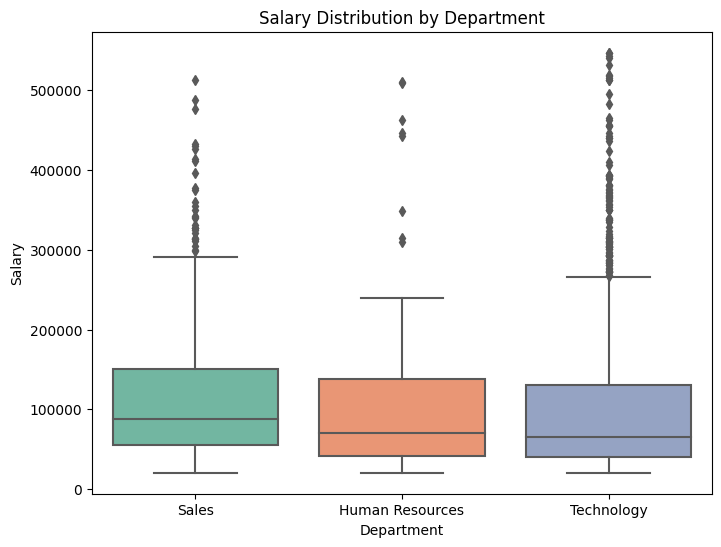

In [19]:
# check for Outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x='Department', y='Salary', data=emp_data, palette='Set2')
plt.title('Salary Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.show()

In [20]:
#age = emp_data[emp_data['Age'] == 25]
age_25=emp_data[emp_data["Age"]==25]
age_25=age_25[age_25['Salary']>200000]
age_25[['Salary','Age']]

,Salary,Age
579,217544,25
606,211401,25
702,243908,25
722,261970,25
765,204154,25
793,285138,25
814,303446,25


In [21]:
high_salaries = emp_data[emp_data['Salary'] > 500000]
high_salaries.head(13)

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
65,5731-90E6,Leonidas,Clarke-Williams,Non-Binary,35,No Travel,Technology,27,CA,Asian or Asian American,...,Single,542695,0,No,2012-03-02,No,10,5,5,1
159,16FB-8835,Albina,Baston,Female,46,Frequent Traveller,Technology,24,NY,White,...,Married,514945,0,Yes,2013-02-05,No,9,4,7,7
239,134B-4157,Stearne,Axelbee,Male,37,Some Travel,Technology,29,IL,White,...,Married,513608,0,No,2013-09-03,No,9,4,7,3
385,17AE-E715,Norbie,Mosdill,Male,31,Frequent Traveller,Technology,38,CA,White,...,Divorced,547204,1,Yes,2014-09-28,No,8,7,8,5
397,DF63-0D3C,Roda,Costin,Female,28,Frequent Traveller,Technology,27,CA,White,...,Married,546549,1,No,2014-11-18,No,8,8,8,2
597,4294-03D1,Lettie,D'Emanuele,Female,43,Some Travel,Sales,12,CA,White,...,Married,513262,0,No,2016-06-30,No,6,1,3,1
774,5639-70C0,Trudi,Evens,Female,36,Some Travel,Human Resources,31,IL,Black or African American,...,Divorced,509940,3,No,2018-01-15,No,4,4,4,2
934,3CFD-6622,Adelina,Bittlestone,Female,40,Frequent Traveller,Technology,19,CA,Black or African American,...,Single,513325,0,No,2019-03-10,No,3,0,0,1
961,8892-77D8,Rodrique,Rohlfing,Male,35,Some Travel,Technology,29,CA,Mixed or multiple ethnic groups,...,Divorced,519361,1,Yes,2019-05-04,No,3,2,3,1
1031,43DD-6998,Angelia,Letrange,Female,48,Some Travel,Technology,9,CA,White,...,Divorced,517695,1,No,2019-10-29,No,3,2,2,3


In [22]:
high_salaries.groupby("Department")[['JobRole']].value_counts()

Department       JobRole            
Human Resources  HR Manager             2
Sales            Manager                1
Technology       Analytics Manager      7
                 Engineering Manager    3
Name: count, dtype: int64

In [23]:
roles_to_filter = ['Data Scientist', 'Machine Learning Engineer', 'Software Engineer', 'Sales Executive']

filtered_d = high_salaries[high_salaries['JobRole'].isin(roles_to_filter)]
filtered_d.head() #There are no outlier as high salaries belong to mangers and empolee with high age(experiences)

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager


# **Data Analysis**

In [24]:
# Counting of different gender  
emp_data['Gender'].value_counts()

Gender
Female               675
Male                 651
Non-Binary           124
Prefer Not To Say     20
Name: count, dtype: int64

In [25]:
# Group data by Department and Gender, then count occurrences
gender_distribution = (
    emp_data.groupby(['Department', 'Gender']).size().unstack(fill_value=0))
gender_distribution = gender_distribution.div(gender_distribution.sum(axis=1), axis=0) *100
gender_distribution

Gender,Female,Male,Non-Binary,Prefer Not To Say
Department,,,,
Human Resources,52.380952,38.095238,7.936508,1.587302
Sales,45.739910,45.739910,7.847534,0.672646
Technology,45.577523,44.016649,8.740895,1.664932


In [26]:
#Net of Employees of different ethnicity group
emp_data['Ethnicity'].value_counts()

Ethnicity
White                               860
Black or African American           207
Mixed or multiple ethnic groups     198
Asian or Asian American             113
American Indian or Alaska Native     50
Native Hawaiian                      26
Other                                16
Name: count, dtype: int64

 **Salary by Gender**

In [27]:
# Calculate the average salary by gender
average_salary_by_gender = round(emp_data.groupby('Gender')['Salary'].median(),2)
print(average_salary_by_gender.sort_values(ascending=False))

Gender
Prefer Not To Say    89244.0
Non-Binary           76608.5
Male                 71698.0
Female               69747.0
Name: Salary, dtype: float64


 **Salary by Department**

In [28]:
# Calculate the average salary by department 
average_salary_by_gender = round(emp_data.groupby('Department')['Salary'].median(),2)
print(average_salary_by_gender.sort_values(ascending=False))

Department
Sales              88005.5
Human Resources    70395.0
Technology         64887.0
Name: Salary, dtype: float64


**Which education field has the highest average salary?**

In [29]:
# Find the education field with the highest average salary 
highest_salary_by_education = round(emp_data.groupby('Ethnicity')['Salary'].median().sort_values(ascending=False),2)
print(highest_salary_by_education)

Ethnicity
American Indian or Alaska Native    84475.5
Asian or Asian American             77136.0
Mixed or multiple ethnic groups     75455.0
Black or African American           73643.0
White                               69373.0
Native Hawaiian                     59731.0
Other                               59150.5
Name: Salary, dtype: float64


In [30]:
# Find the Job Role with the highest average salary 
highest_salary_by_education = round(emp_data.groupby('JobRole')['Salary'].median().sort_values(ascending=False),2)
print(highest_salary_by_education)

JobRole
HR Manager                   486156.0
Analytics Manager            355858.5
Manager                      313891.0
HR Business Partner          309964.0
Engineering Manager          292500.0
Senior Software Engineer     106898.5
Sales Executive              100314.0
Machine Learning Engineer     98598.5
HR Executive                  89376.0
Data Scientist                44057.0
Software Engineer             42704.0
Sales Representative          36101.0
Recruiter                     30853.5
Name: Salary, dtype: float64


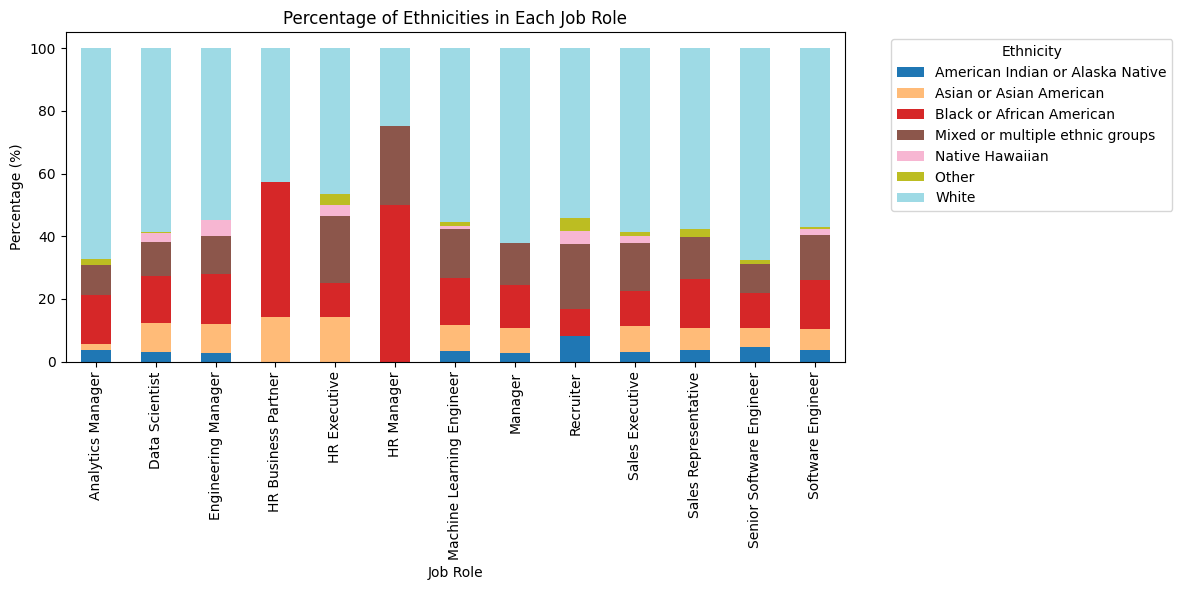

In [31]:
# the percentage of each ethinicity in job role
ethnicity_job_percent = pd.crosstab(emp_data['JobRole'], emp_data['Ethnicity'], normalize='index') * 100

# Round for cleaner display
ethnicity_job_percent = ethnicity_job_percent.round(2)

ethnicity_job_percent.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title("Percentage of Ethnicities in Each Job Role")
plt.xlabel("Job Role")
plt.ylabel("Percentage (%)")
plt.legend(title="Ethnicity", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [32]:
# average Salary by Gender and Department
avg_salary_by_gender_dept = emp_data.groupby(['Department', 'Gender'])['Salary'].median().round(2)

avg_salary_table = avg_salary_by_gender_dept.unstack()
print(avg_salary_table)


Gender            Female     Male  Non-Binary  Prefer Not To Say
Department                                                      
Human Resources  55206.0  75192.5     99052.0            30683.0
Sales            91267.0  86813.5     81889.0            90726.0
Technology       65650.5  62756.0     69231.5            95595.5


**What is the distribution of employees by age group?**

In [33]:
# Create age groups and count employees in each group 
bins = [0, 20, 30, 40, 50, 60]
labels = ['<20', '20-30', '30-40', '40-50', '+50']
emp_data['AgeGroup'] = pd.cut(emp_data['Age'], bins=bins, labels=labels)
age_distribution = emp_data['AgeGroup'].value_counts()
print(age_distribution)

AgeGroup
20-30    873
30-40    278
40-50    192
<20      126
+50        1
Name: count, dtype: int64


**From which state the most emploee come from**

In [34]:
emp_data['State'].value_counts()

State
CA    875
NY    419
IL    176
Name: count, dtype: int64

**Occurrences of Satisfaction level**

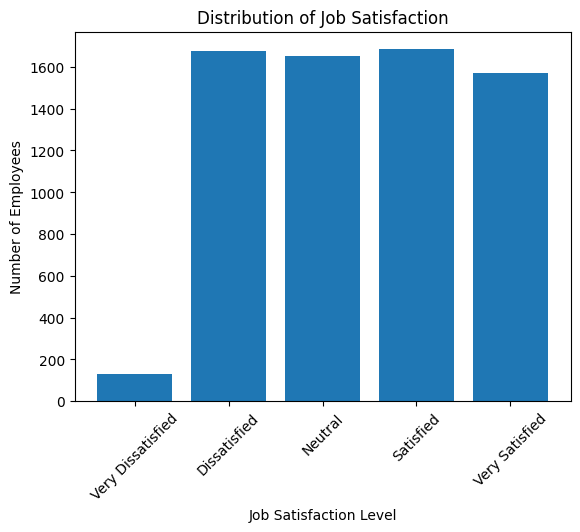

In [35]:
# Count occurrences of each satisfaction level
satisfaction_counts = perf_data['JobSatisfaction'].value_counts().sort_index()

# Plot the distribution
plt.bar(satisfaction_counts.index, satisfaction_counts.values)
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Number of Employees')
plt.title('Distribution of Job Satisfaction')
plt.xticks([1, 2, 3, 4, 5], ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied'])
plt.xticks(rotation=45)
plt.show()

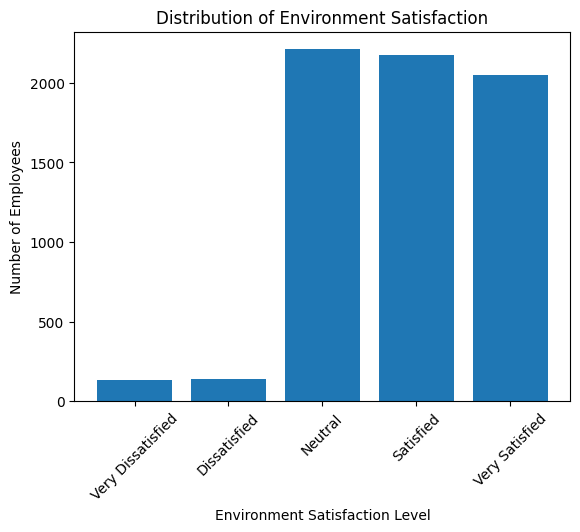

In [36]:
# Count occurrences of Environment satisfaction level
satisfaction_counts = perf_data['EnvironmentSatisfaction'].value_counts().sort_index()

# Plot the distribution
plt.bar(satisfaction_counts.index, satisfaction_counts.values)
plt.xlabel('Environment Satisfaction Level')
plt.ylabel('Number of Employees')
plt.title('Distribution of Environment Satisfaction')
plt.xticks([1, 2, 3, 4, 5], ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied'])
plt.xticks(rotation=45)
plt.show()

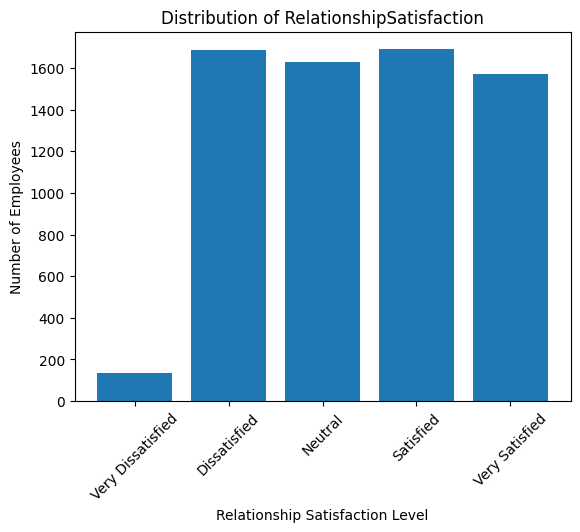

In [37]:
# Occurrences of Relationship Satisfaction level
satisfaction_counts = merged_data['RelationshipSatisfaction'].value_counts().sort_index()

# Plot the distribution
plt.bar(satisfaction_counts.index, satisfaction_counts.values)
plt.xlabel('Relationship Satisfaction Level')
plt.ylabel('Number of Employees')
plt.title('Distribution of RelationshipSatisfaction')
plt.xticks([1, 2, 3, 4, 5], ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied'])
plt.xticks(rotation=45)
plt.show()

**How does job satisfaction vary across different ethnic groups?**

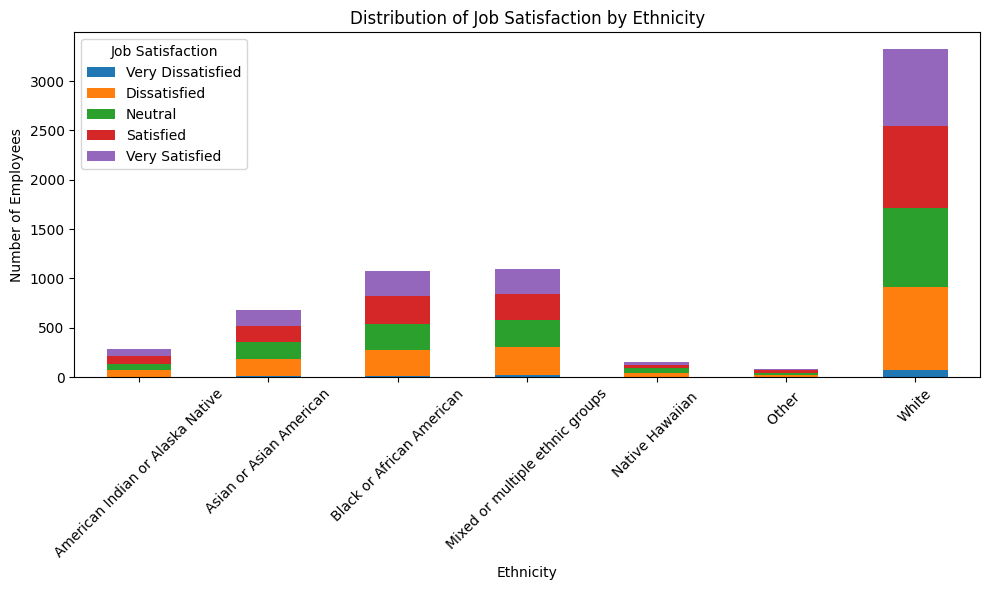

In [125]:
# Group by Ethnicity and JobSatisfaction, then count occurrences
satisfaction_by_ethnicity = (
    merged_data.groupby(['Ethnicity', 'JobSatisfaction']).size().unstack(fill_value=0)
)


satisfaction_by_ethnicity.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.xlabel('Ethnicity')
plt.ylabel('Number of Employees')
plt.title('Distribution of Job Satisfaction by Ethnicity')
plt.xticks(rotation=45)  
plt.legend(title='Job Satisfaction', labels=['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied'])
plt.tight_layout() 
plt.show()

**What is the average tenure of employees in the company?**

In [127]:
# Calculate the average years at the company  
average_tenure =round( emp_data['YearsAtCompany'].mean(),2)
print(average_tenure)

4.56


**What is the trend of hires over time?**

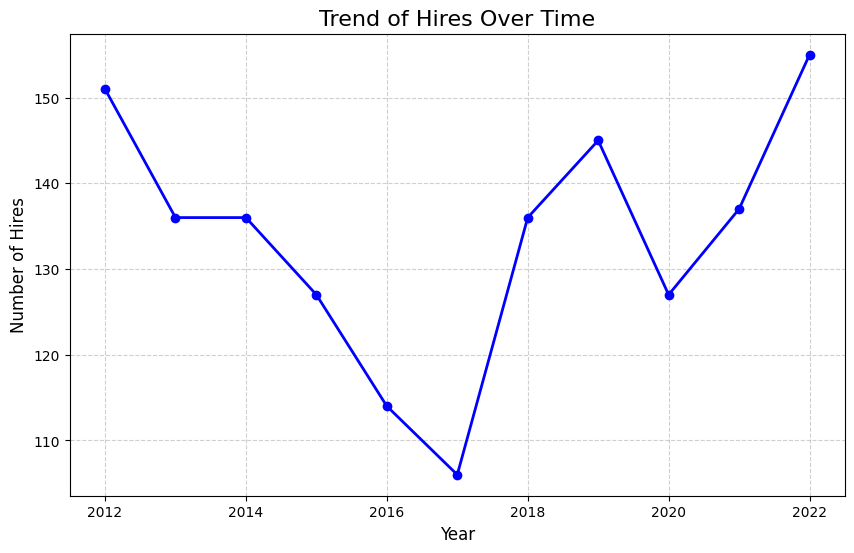

In [128]:
hiring_trends = emp_data.groupby(emp_data['HireDate'].dt.year).size()
# Plot the hiring trend over time
plt.figure(figsize=(10, 6))
plt.plot(hiring_trends.index, hiring_trends.values, marker='o', color='b', linestyle='-', linewidth=2)
plt.title('Trend of Hires Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Hires', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout
plt.show()

**How does satisfaction vary by department?**

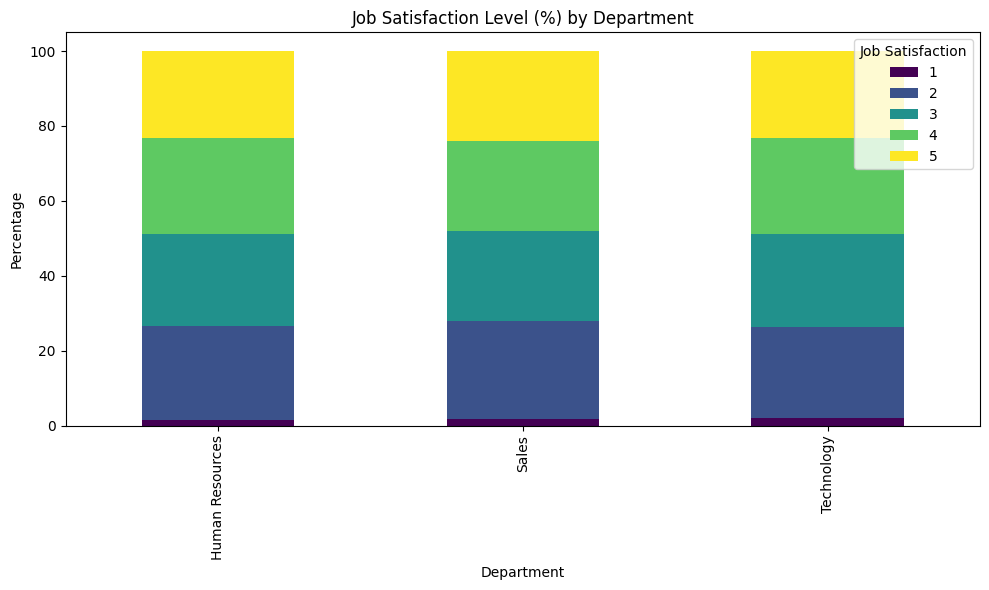

In [130]:
# Example: Percentage of JobSatisfaction levels across departments
job_sat_pct = pd.crosstab(merged_data['Department'], merged_data['JobSatisfaction'], normalize='index') * 100
job_sat_pct = job_sat_pct.round(2)

job_sat_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title("Job Satisfaction Level (%) by Department")
plt.xlabel("Department")
plt.ylabel("Percentage")
plt.legend(title="Job Satisfaction")
plt.tight_layout()
plt.show()

In [132]:
# Job Satisfaction by Dapartment
env_satisfaction_by_dept = (
    merged_data.groupby('Department')['JobSatisfaction'].mean().sort_values()) 

print(env_satisfaction_by_dept.sort_values(ascending=False))

Department
Human Resources    3.435644
Technology         3.434578
Sales              3.422057
Name: JobSatisfaction, dtype: float64


In [133]:
# Relationship Satisfaction by Dapartment
env_satisfaction_by_dept = (
    merged_data.groupby('Department')['RelationshipSatisfaction'].mean().sort_values()) 

print(env_satisfaction_by_dept.sort_values(ascending=False))

Department
Sales              3.451838
Technology         3.420249
Human Resources    3.353135
Name: RelationshipSatisfaction, dtype: float64


**How many employees have not been promoted in the last 5 years?**

In [38]:
# Count employees who haven't been promoted in the last 5 years
no_promotion_in_5_years = (emp_data[emp_data['YearsSinceLastPromotion'] >= 5].shape[0] / emp_data.shape[0]) *100
print(round(no_promotion_in_5_years,2))

33.67










**What is the average time since the last promotion?**

In [135]:
# Calculate the average years since the last promotion
avg_years_since_promotion = emp_data['YearsSinceLastPromotion'].mean()
print(f"Average Years Since Last Promotion: {avg_years_since_promotion:.2f}")

Average Years Since Last Promotion: 3.44


**What is the average number of training opportunities taken per year?**

In [136]:
# Calculate the average training opportunities taken per year 
avg_training_opportunities_taken = merged_data['TrainingOpportunitiesTaken'].mean()
print(round(avg_training_opportunities_taken,2))

1.02


In [137]:
# Correlation between training opportunities taken and job satisfaction
correlation = merged_data[['TrainingOpportunitiesTaken', 'JobSatisfaction']].corr()
print(correlation)

                            TrainingOpportunitiesTaken  JobSatisfaction
TrainingOpportunitiesTaken                    1.000000         0.002729
JobSatisfaction                               0.002729         1.000000


**What is the relationship between self-rating and manager rating?**

In [138]:
correlation = perf_data[['SelfRating', 'ManagerRating']].corr()
print(correlation)

               SelfRating  ManagerRating
SelfRating       1.000000       0.854107
ManagerRating    0.854107       1.000000


In [139]:
# Correlation between training opportunities taken and manager rating
correlation = merged_data[['TrainingOpportunitiesTaken', 'ManagerRating']].corr()
print(correlation)

                            TrainingOpportunitiesTaken  ManagerRating
TrainingOpportunitiesTaken                    1.000000       0.008496
ManagerRating                                 0.008496       1.000000


**Are employees low YearsWithCurrManager less satisfied with their jobs?**

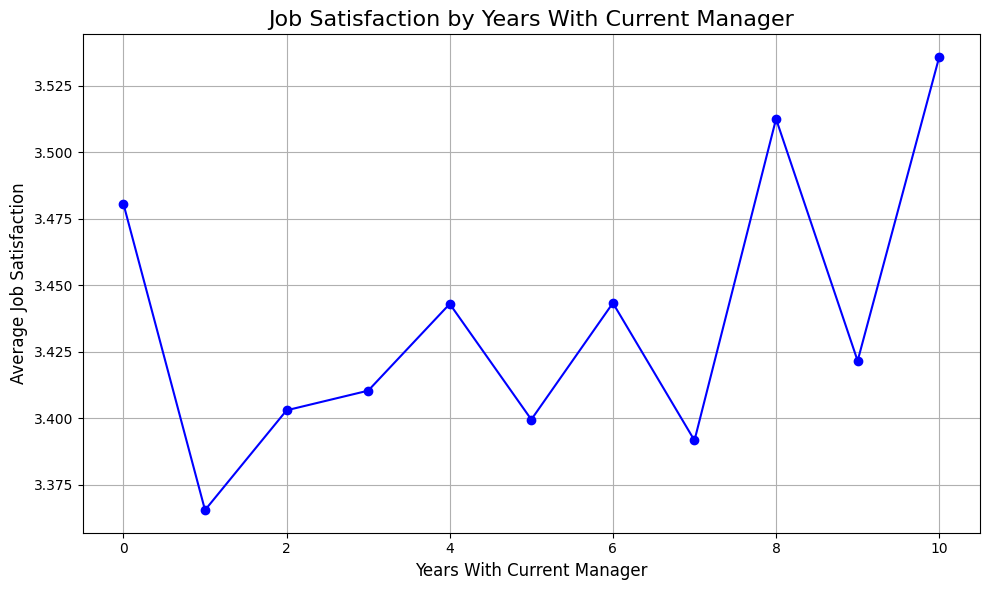

In [140]:
# Group by YearsWithCurrManager and calculate average job satisfaction
job_satisfaction_by_manager_tenure = merged_data.groupby('YearsWithCurrManager')['JobSatisfaction'].mean()

# Plot the results
job_satisfaction_by_manager_tenure.plot(kind='line', figsize=(10, 6), marker='o', color='blue')
plt.title('Job Satisfaction by Years With Current Manager', fontsize=16)
plt.xlabel('Years With Current Manager', fontsize=12)
plt.ylabel('Average Job Satisfaction', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

**How does work-life balance affect employee performance ratings?**

In [141]:
# Compare work-life balance with performance ratings
work_life_balance_vs_performance = merged_data.groupby('WorkLifeBalance')['SelfRating'].mean()
print(work_life_balance_vs_performance.sort_values(ascending=False))

WorkLifeBalance
5    3.999338
4    3.997655
2    3.982374
3    3.966467
1    3.867769
Name: SelfRating, dtype: float64


**How does marital status affect work-life balance?**

In [142]:
# Analyze work-life balance by marital status
work_life_balance_by_marital_status = merged_data.groupby('MaritalStatus')['WorkLifeBalance'].mean()
print(work_life_balance_by_marital_status.sort_values(ascending=False))

MaritalStatus
Married     3.445337
Single      3.405043
Divorced    3.366208
Name: WorkLifeBalance, dtype: float64


**How do these metrics(YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager)vary by gender or ethnicity?**

In [143]:
# Analyze YearsInMostRecentRole by gender
years_in_role_by_gender = merged_data.groupby('Gender')['YearsInMostRecentRole'].mean()
print(years_in_role_by_gender)

Gender
Female               2.979942
Male                 2.622978
Non-Binary           3.322581
Prefer Not To Say    3.065574
Name: YearsInMostRecentRole, dtype: float64


In [144]:
# Analyze YearsSinceLastPromotion by gender
years_in_role_by_gender = merged_data.groupby('Gender')['YearsSinceLastPromotion'].mean()
print(years_in_role_by_gender)

Gender
Female               4.400518
Male                 4.011792
Non-Binary           4.645161
Prefer Not To Say    4.852459
Name: YearsSinceLastPromotion, dtype: float64


In [145]:
# YearsSinceLastPromotion by ethnicity
years_since_promotion_by_ethnicity = merged_data.groupby('Ethnicity')['YearsSinceLastPromotion'].mean()
print(years_since_promotion_by_ethnicity)

Ethnicity
American Indian or Alaska Native    4.433099
Asian or Asian American             4.979502
Black or African American           4.666667
Mixed or multiple ethnic groups     4.480437
Native Hawaiian                     4.057325
Other                               3.885057
White                               3.901442
Name: YearsSinceLastPromotion, dtype: float64


In [146]:
# Analyze YearsInMostRecentRole by Ethnicity
years_in_role_by_gender = merged_data.groupby('Ethnicity')['YearsInMostRecentRole'].mean()
print(years_in_role_by_gender)

Ethnicity
American Indian or Alaska Native    2.507042
Asian or Asian American             3.448023
Black or African American           3.112979
Mixed or multiple ethnic groups     3.101911
Native Hawaiian                     2.719745
Other                               2.471264
White                               2.610577
Name: YearsInMostRecentRole, dtype: float64


In [147]:
# YearsWithCurrManager by job role
years_with_manager_by_job_role = merged_data.groupby('JobRole')['YearsWithCurrManager'].mean()
print(years_with_manager_by_job_role)

JobRole
Analytics Manager            2.562500
Data Scientist               2.895588
Engineering Manager          3.225166
HR Business Partner          5.260870
HR Executive                 3.617391
HR Manager                   4.187500
Machine Learning Engineer    2.767025
Manager                      3.642857
Recruiter                    2.718121
Sales Executive              2.671926
Sales Representative         2.036810
Senior Software Engineer     3.356275
Software Engineer            2.741379
Name: YearsWithCurrManager, dtype: float64


In [148]:
# YearsWithCurrManager by Ethnicity
years_with_manager_by_job_role = merged_data.groupby('Ethnicity')['YearsWithCurrManager'].mean()
print(years_with_manager_by_job_role)

Ethnicity
American Indian or Alaska Native    2.707746
Asian or Asian American             3.512445
Black or African American           3.108310
Mixed or multiple ethnic groups     2.826206
Native Hawaiian                     2.751592
Other                               1.931034
White                               2.608173
Name: YearsWithCurrManager, dtype: float64


# **Attrition Analysis**

In [149]:
#Overall Atrrition
attrition_rate = emp_data['Attrition'].value_counts(normalize=True)['Yes'] * 100
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 16.12%


In [150]:
#How many employees have left the organization?
attrition_count =emp_data['Attrition'].value_counts()['Yes']
print(f"Number of employees who left: {attrition_count}")

Number of employees who left: 237


In [151]:
#What is the average age of employees who left versus those who stayed?
avg_age_attrition = emp_data.groupby('Attrition')['Age'].mean()
print(avg_age_attrition)

Attrition
No     29.460665
Yes    26.540084
Name: Age, dtype: float64


In [152]:
#What is the average salary of employees who left versus those who stayed?
avg_salary_attrition = emp_data.groupby('Attrition')['Salary'].median()
print(avg_salary_attrition)

Attrition
No     75816.0
Yes    50660.0
Name: Salary, dtype: float64


In [153]:
# Calculate average years since last promotion for employees with attrition
avg_years_since_promotion = round(emp_data[emp_data['Attrition'] == 'Yes']['YearsSinceLastPromotion'].mean(),2)
print(avg_years_since_promotion)

1.44


In [154]:
# Calculate the average distance from home for employees with attrition
avg_distance_for_attrition = round(emp_data[emp_data['Attrition'] == 'Yes']['DistanceFromHome (KM)'].mean(),2)
print(avg_distance_for_attrition)
plt.show()

22.22


In [155]:
#What is the average TrainingOpportunitiesWithinYear for employees who left?
avg_training_attrition = merged_data[merged_data['Attrition'] == 'Yes']['TrainingOpportunitiesWithinYear'].mean()
print(f"Average Training Opportunities for employees who left: {avg_training_attrition:.2f}%")

Average Training Opportunities for employees who left: 2.01%


**1. Demographic Factors**

> What is the attrition rate by gender? 

In [157]:
attrition_by_gender= (
    emp_data.groupby('Gender')['Attrition']
    .value_counts(normalize=True)  
    .unstack() *100 
)
print(attrition_by_gender.sort_values(by=['Yes'], ascending=False))

Attrition                  No        Yes
Gender                                  
Male                82.488479  17.511521
Female              84.592593  15.407407
Non-Binary          84.677419  15.322581
Prefer Not To Say  100.000000        NaN


/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


> Attrition rate by Age

In [158]:
attrition_by_age= (
    emp_data.groupby('Age')['Attrition']
    .value_counts(normalize=True)  
    .unstack() *100 
)
print(attrition_by_gender.sort_values(by=['Yes'], ascending=False))

Attrition                  No        Yes
Gender                                  
Male                82.488479  17.511521
Female              84.592593  15.407407
Non-Binary          84.677419  15.322581
Prefer Not To Say  100.000000        NaN


/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [159]:
# Create age groups and count employees in each group
bins = [ 20, 30, 40, 50, 60]
labels = ['20-30', '30-40', '40-50', '+50']
emp_data['AgeGroup'] = pd.cut(emp_data['Age'], bins=bins, labels=labels)
attrition_by_age = emp_data.groupby('AgeGroup')['Attrition'].value_counts(normalize=True).unstack() * 100
print(attrition_by_age.sort_values(by=['Yes'], ascending=False))

Attrition          No        Yes
AgeGroup                        
20-30       79.495991  20.504009
40-50       92.708333   7.291667
30-40       93.165468   6.834532
+50        100.000000   0.000000


<ipython-input-159-7a94344444f8>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_by_age = emp_data.groupby('AgeGroup')['Attrition'].value_counts(normalize=True).unstack() * 100


>  Does marital status influence attrition?


Attrition             No        Yes
MaritalStatus                      
Single         76.684882  23.315118
Married        87.339744  12.660256
Divorced       89.898990  10.101010


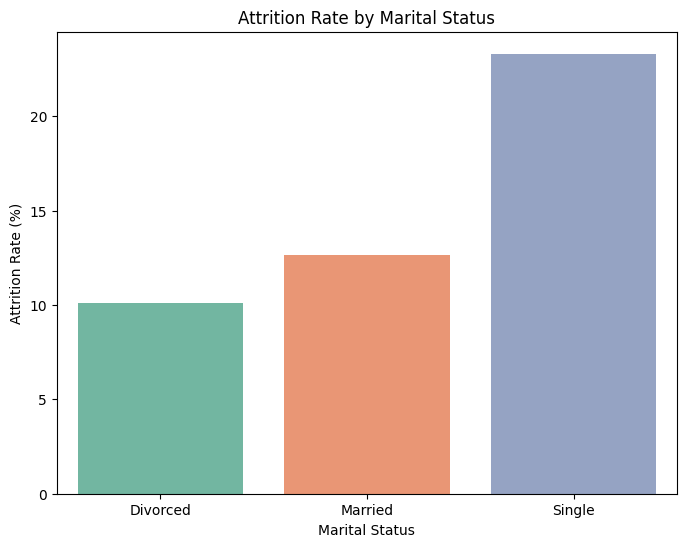

In [160]:
attrition_by_marital_status = emp_data.groupby('MaritalStatus')['Attrition'].value_counts(normalize=True).unstack() * 100
print(attrition_by_marital_status.sort_values(by=['Yes'], ascending=False))
plt.figure(figsize=(8, 6))
sns.barplot(x=attrition_by_marital_status.index, y=attrition_by_marital_status['Yes'], palette='Set2')
plt.title('Attrition Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Attrition Rate (%)')
plt.show()

> Is there a difference in attrition rates across ethnic groups?

Attrition                                No        Yes
Ethnicity                                             
Native Hawaiian                   76.923077  23.076923
American Indian or Alaska Native  78.000000  22.000000
Mixed or multiple ethnic groups   83.838384  16.161616
White                             84.069767  15.930233
Asian or Asian American           84.070796  15.929204
Black or African American         85.024155  14.975845
Other                             87.500000  12.500000


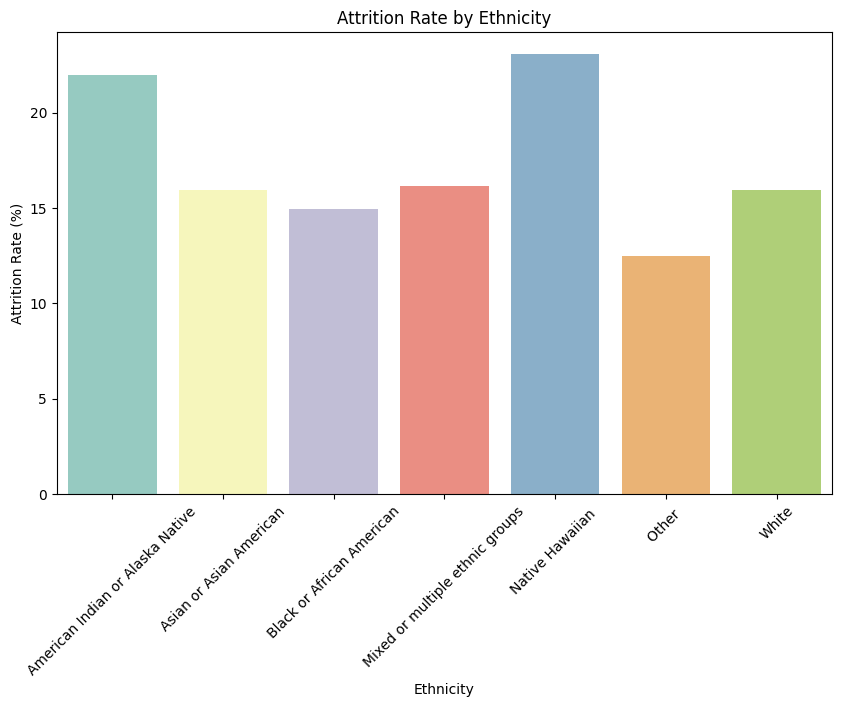

In [161]:
attrition_by_ethnicity = emp_data.groupby('Ethnicity')['Attrition'].value_counts(normalize=True).unstack() * 100
print(attrition_by_ethnicity.sort_values(by=['Yes'], ascending=False))
plt.figure(figsize=(10, 6))
sns.barplot(x=attrition_by_ethnicity.index, y=attrition_by_ethnicity['Yes'], palette='Set3')
plt.title('Attrition Rate by Ethnicity')
plt.xlabel('Ethnicity')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.show()

**2.  Work-Related Factors**

> How does department affect attrition?

In [162]:
# Calculate the attrition rate by department
attrition_by_dept = (
    emp_data.groupby('Department')['Attrition']
    .value_counts(normalize=True)  # Normalize to get percentages
    .unstack() *100 # Reshape for better readability
)
print(attrition_by_dept.sort_values(by=['Yes'], ascending=False))

Attrition               No        Yes
Department                           
Sales            79.372197  20.627803
Human Resources  80.952381  19.047619
Technology       86.160250  13.839750


> How does job role affect attrition?

In [163]:
attrition_by_job_role = emp_data.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack() * 100
print(attrition_by_job_role.sort_values(by=['Yes'], ascending=False))

Attrition                          No        Yes
JobRole                                         
Sales Representative        60.240964  39.759036
Recruiter                   62.500000  37.500000
Data Scientist              76.245211  23.754789
Sales Executive             82.568807  17.431193
Software Engineer           84.013605  15.986395
HR Executive                89.285714  10.714286
Machine Learning Engineer   93.150685   6.849315
Senior Software Engineer    93.181818   6.818182
Analytics Manager           94.230769   5.769231
Manager                     94.594595   5.405405
Engineering Manager         97.333333   2.666667
HR Business Partner        100.000000        NaN
HR Manager                 100.000000        NaN


/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


> What is the relationship between overtime and attrition?


In [164]:
# Analyze attrition rates based on overtime
overtime_attrition = (
    emp_data.groupby('OverTime')['Attrition']
    .value_counts(normalize=True)
    .unstack() * 100
)
print(overtime_attrition.sort_values(by=['Yes'], ascending=False))


Attrition         No        Yes
OverTime                       
Yes        69.471154  30.528846
No         89.563567  10.436433



 **Tenure and Experience**

> What is the attrition rate by years since last promotion?

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


Attrition                        No        Yes
YearsSinceLastPromotion                       
0                         62.126246  37.873754
1                         75.355450  24.644550
3                         87.951807  12.048193
2                         90.000000  10.000000
5                         90.517241   9.482759
4                         92.517007   7.482993
6                         95.370370   4.629630
7                         95.454545   4.545455
9                         96.103896   3.896104
8                         97.058824   2.941176
10                       100.000000        NaN


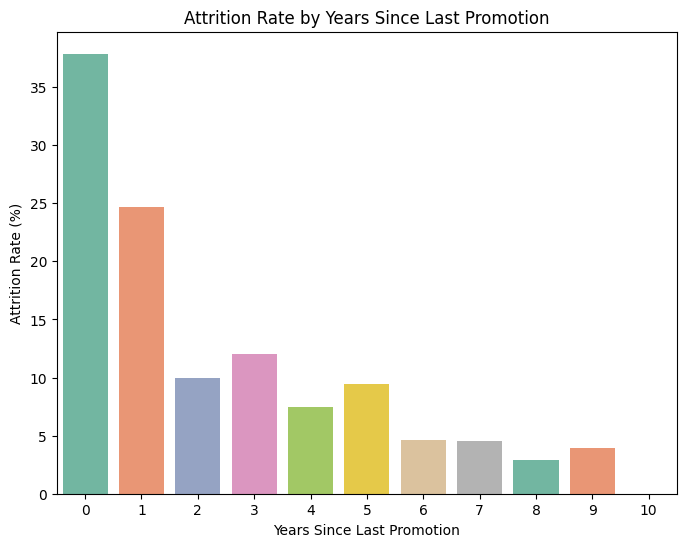

In [165]:
attrition_by_years_with_manager = emp_data.groupby('YearsSinceLastPromotion')['Attrition'].value_counts(normalize=True).unstack() * 100
print(attrition_by_years_with_manager.sort_values(by=['Yes'], ascending=False))
plt.figure(figsize=(8, 6))
sns.barplot(x=attrition_by_years_with_manager.index, y=attrition_by_years_with_manager['Yes'], palette='Set2')
plt.title('Attrition Rate by Years Since Last Promotion')
plt.xlabel('Years Since Last Promotion')
plt.ylabel('Attrition Rate (%)')
plt.show()


> What is the attrition rate by years at company?

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


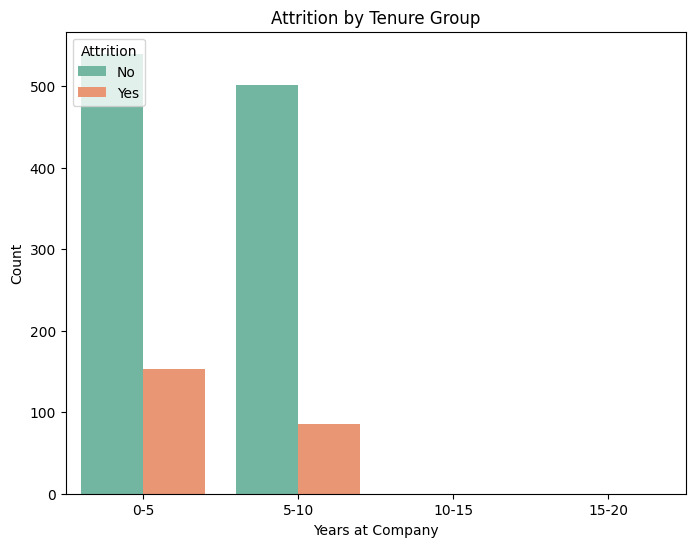

In [166]:

merged_data['TenureGroup'] = pd.cut(emp_data['YearsAtCompany'], bins=[0, 5, 10, 15, 20], labels=['0-5', '5-10', '10-15', '15-20'])

# Plot attrition by tenure group
plt.figure(figsize=(8, 6))
sns.countplot(x='TenureGroup', hue='Attrition', data=merged_data, palette='Set2')
plt.title('Attrition by Tenure Group')
plt.xlabel('Years at Company')
plt.ylabel('Count')
plt.show()



> What is the attrition rate by  years with_manager?

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


Attrition                     No        Yes
YearsWithCurrManager                       
0                      72.651357  27.348643
1                      82.534247  17.465753
2                      86.910995  13.089005
6                      90.476190   9.523810
3                      91.366906   8.633094
5                      91.780822   8.219178
7                      95.918367   4.081633
4                      96.116505   3.883495
8                     100.000000        NaN
9                     100.000000        NaN
10                    100.000000        NaN


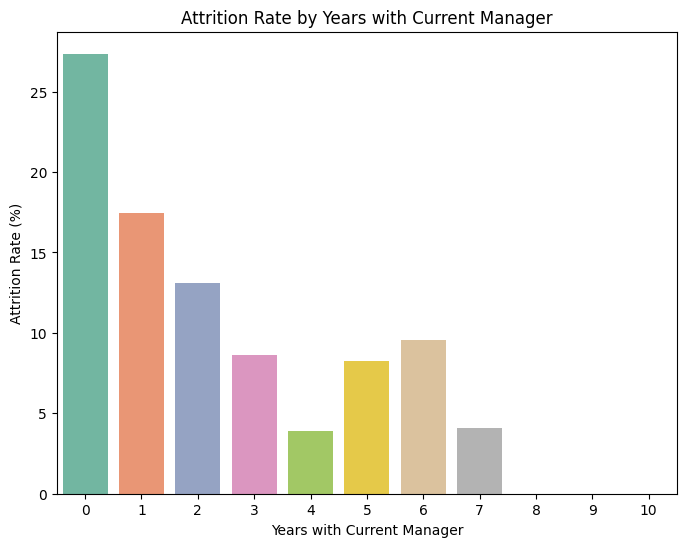

In [167]:
attrition_by_years_with_manager = emp_data.groupby('YearsWithCurrManager')['Attrition'].value_counts(normalize=True).unstack() * 100
print(attrition_by_years_with_manager.sort_values(by=['Yes'], ascending=False))
plt.figure(figsize=(8, 6))
sns.barplot(x=attrition_by_years_with_manager.index, y=attrition_by_years_with_manager['Yes'], palette='Set2')
plt.title('Attrition Rate by Years with Current Manager')
plt.xlabel('Years with Current Manager')
plt.ylabel('Attrition Rate (%)')
plt.show()

In [168]:
# rows where Attrition is 'Yes' and YearsWithCurrManager is either 0 or 1
filtered_data = emp_data[(emp_data['Attrition'] == 'Yes') & 
                            (emp_data['YearsWithCurrManager'].isin([0, 1]))]
#specifiy the Agegroup 
filtered_data['AgeGroup'].value_counts()

AgeGroup
20-30    135
30-40     14
40-50      8
+50        0
Name: count, dtype: int64

**Benefits**

> Does salary level correlate with attrition?

<ipython-input-50-e67b08e6cc60>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emp_data.groupby('SalaryGroup')['Attrition']


Attrition              No        Yes
SalaryGroup                         
20000-100000    80.404686  19.595314
+500000         84.615385  15.384615
200000-300000   89.051095  10.948905
100000-200000   89.323843  10.676157
300000-400000   92.000000   8.000000
400000-500000  100.000000   0.000000


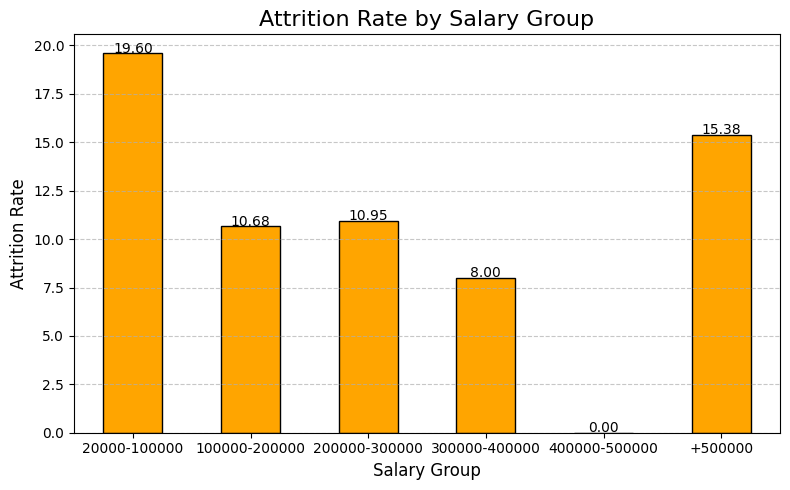

In [50]:
salary_bins = [20000,100000, 200000, 300000, 400000, 500000,600000]

salary_labels = ['20000-100000','100000-200000','200000-300000','300000-400000','400000-500000','+500000']

emp_data['SalaryGroup'] = pd.cut(emp_data['Salary'], bins=salary_bins, labels=salary_labels)

attrition_by_salary = (
    emp_data.groupby('SalaryGroup')['Attrition']
    .value_counts(normalize=True)  
    .unstack() *100
)

print(attrition_by_salary.sort_values(by=['Yes'], ascending=False))

plt.figure(figsize=(8, 5))
attrition_by_salary['Yes'].plot(kind='bar', color='orange', edgecolor='black')


plt.title('Attrition Rate by Salary Group', fontsize=16)
plt.xlabel('Salary Group', fontsize=12)
plt.ylabel('Attrition Rate', fontsize=12)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, rate in enumerate(attrition_by_salary['Yes']):
    plt.text(i, rate + 0.02, f'{rate:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

> What is the attrition rate by stock option leve?


Attrition               No       Yes
StockOptionLevel                    
0                 7.559429  2.440571
3                 8.235294  1.764706
1                 9.060403  0.939597
2                 9.240506  0.759494


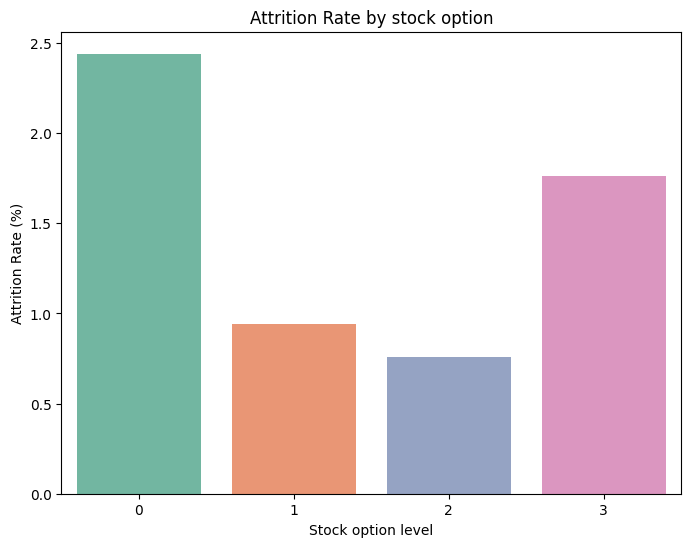

In [171]:
attrition_by_stock_option = emp_data.groupby('StockOptionLevel')['Attrition'].value_counts(normalize=True).unstack() * 10
print(attrition_by_stock_option.sort_values(by=['Yes'], ascending=False))
plt.figure(figsize=(8, 6))
sns.barplot(x=attrition_by_stock_option.index, y=attrition_by_stock_option['Yes'], palette='Set2')
plt.title('Attrition Rate by stock option')
plt.xlabel('Stock option level')
plt.ylabel('Attrition Rate (%)')
plt.show()

In [46]:
stock_3=emp_data[emp_data['StockOptionLevel']==3]
attrition=stock_3[stock_3['Attrition']=="Yes"]
for col in attrition.columns:
    print(attrition[col].value_counts())

EmployeeID
9727-BC84    1
FE2B-3DC7    1
8EE9-E86D    1
D4D5-27FB    1
13E5-2F17    1
E268-61EB    1
4FD5-CC71    1
1799-5B3F    1
B34E-95FF    1
45FF-ACE6    1
8C57-8F84    1
D8FC-E2F7    1
63BF-A86A    1
B005-602F    1
06E8-4FD4    1
Name: count, dtype: int64
FirstName
Murdock    1
Mattie     1
Conn       1
Bengt      1
Vin        1
Dorise     1
Sibley     1
Howey      1
Samuele    1
Korrie     1
Lemmie     1
Gigi       1
Ava        1
Layney     1
Emilee     1
Name: count, dtype: int64
LastName
Spaduzza      1
Wippermann    1
Mouser        1
Keaves        1
Wandless      1
Rossant       1
Jeans         1
Woolis        1
Creek         1
Plampin       1
Antoniak      1
Monkhouse     1
Galland       1
Ratie         1
Wenham        1
Name: count, dtype: int64
Gender
Female    8
Male      7
Name: count, dtype: int64
Age
28    2
24    2
22    2
20    2
31    1
46    1
29    1
21    1
25    1
39    1
19    1
Name: count, dtype: int64
BusinessTravel
Some Travel           12
Frequent Travelle

**Commuting Factors**

> How does business travel frequency impact attrition?

Attrition                  No        Yes
BusinessTravel                          
Frequent Traveller  75.090253  24.909747
Some Travel         85.043145  14.956855
No Travel           92.000000   8.000000


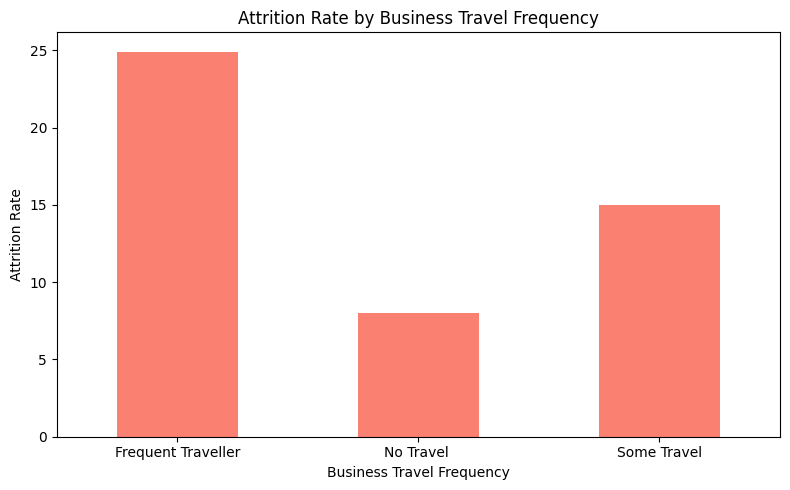

In [172]:
attrition_by_travel = (
    emp_data.groupby('BusinessTravel')['Attrition']
    .value_counts(normalize=True)  
    .unstack() *100
)

# Display the results
print(attrition_by_travel.sort_values(by=['Yes'], ascending=False))


# Plot the results
attrition_by_travel['Yes'].plot(kind='bar', color='salmon', figsize=(8, 5))

# Add labels and title
plt.title('Attrition Rate by Business Travel Frequency')
plt.xlabel('Business Travel Frequency')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=0)  # No rotation needed for short labels
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

> Does distance from home affect attrition?

In [173]:

emp_data['DistanceFromHome (KM)'] = pd.to_numeric(emp_data['DistanceFromHome (KM)'], errors='coerce')

# Define bins and labels
bins = [1, 5, 10, 15, 20, 25, 30, 35, 40]
labels = ['<5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35-40']

# Create age groups and count employees in each group
emp_data['DistanceGroup'] = pd.cut(emp_data['DistanceFromHome (KM)'], bins=bins, labels=labels)

# Count the distribution of employees in each distance group
distance_distribution = emp_data['DistanceGroup'].value_counts().sort_index()
print(distance_distribution)

DistanceGroup
<5       147
5-10     156
10-15    158
15-20    187
20-25    163
25-30    176
30-35    151
35-40    155
Name: count, dtype: int64


<ipython-input-174-f48f1088b4e0>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emp_data.groupby('DistanceGroup')['Attrition']


Attrition             No        Yes
DistanceGroup                      
<5             80.952381  19.047619
15-20          82.887701  17.112299
5-10           83.333333  16.666667
30-35          84.105960  15.894040
20-25          84.662577  15.337423
10-15          85.443038  14.556962
25-30          86.363636  13.636364
35-40          86.451613  13.548387


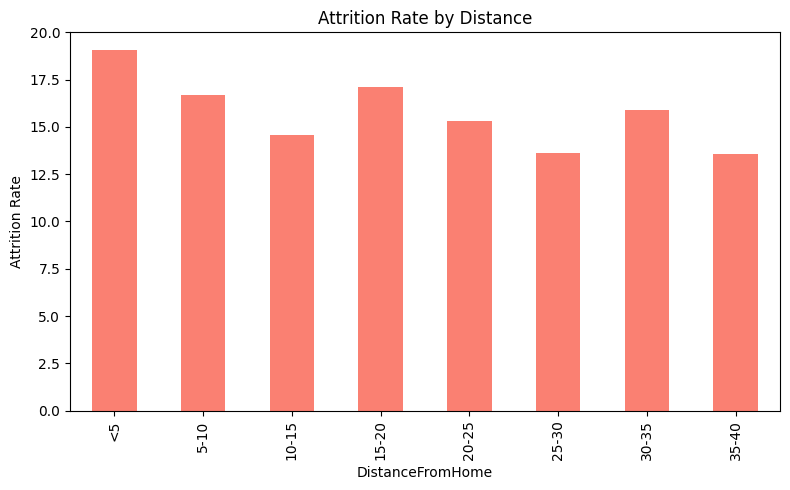

In [174]:
#attrition_by_distance
attrition_by_distance = (
    emp_data.groupby('DistanceGroup')['Attrition']
    .value_counts(normalize=True)  
    .unstack() *100 )

print(attrition_by_distance.sort_values(by=['Yes'], ascending=False))
attrition_by_distance['Yes'].plot(kind='bar', color='salmon', figsize=(8, 5))

# Add labels and title
plt.title('Attrition Rate by Distance')
plt.xlabel('DistanceFromHome')
plt.ylabel('Attrition Rate')
plt.tight_layout()  
plt.show()

>  Which state has the highest attrition rate?

In [175]:
# Calculate attrition rate by state
attrition_by_state = (
    emp_data.groupby('State')['Attrition']
    .value_counts(normalize=True)
    .unstack() *100
)
print(attrition_by_state.sort_values(by=['Yes'],ascending=False))

Attrition         No        Yes
State                          
CA         82.514286  17.485714
IL         85.227273  14.772727
NY         86.157518  13.842482


**Satisfaction and Rating**

> Does environment satisfaction correlate with attrition?

In [176]:
# Attrition rate by  Environment Satisfaction
attrition_by_state = (
    merged_data.groupby('EnvironmentSatisfaction')['Attrition']
    .value_counts(normalize=True)
    .unstack() *100
)
print(attrition_by_state.sort_values(by=['Yes'],ascending=False))

Attrition                       No        Yes
EnvironmentSatisfaction                      
3                        64.902759  35.097241
5                        65.786901  34.213099
4                        67.540230  32.459770
2                        68.794326  31.205674
1                        74.264706  25.735294


> How does job satisfaction influence attrition?

In [177]:
# Attrition rate by Job Satisfaction
attrition_by_state = (
    merged_data.groupby('JobSatisfaction')['Attrition']
    .value_counts(normalize=True)
    .unstack() *100
)
print(attrition_by_state.sort_values(by=['Yes'],ascending=False))

Attrition               No        Yes
JobSatisfaction                      
3                65.596608  34.403392
5                65.901848  34.098152
4                65.994065  34.005935
2                67.204301  32.795699
1                72.307692  27.692308


> Are employees with poor relationships at work more likely to leave?

In [178]:
# Attrition rate by Relationship Satisfaction
attrition_by_state = (
    merged_data.groupby('RelationshipSatisfaction')['Attrition']
    .value_counts(normalize=True)
    .unstack() *100
)
print(attrition_by_state.sort_values(by=['Yes'],ascending=False))

Attrition                        No        Yes
RelationshipSatisfaction                      
5                         65.137030  34.862970
3                         65.805658  34.194342
2                         66.508595  33.491405
4                         67.278107  32.721893
1                         70.802920  29.197080


> How does Self Rating influence attrition?

In [179]:
# SelfRating and Attrition 
attrition_by_self_rating = (
    merged_data.groupby('SelfRating')['Attrition']
    .value_counts(normalize=True) 
    .unstack() * 100
)

# Display the results
print(attrition_by_self_rating.sort_values(by=['Yes'],ascending=False))

Attrition          No        Yes
SelfRating                      
5           66.010078  33.989922
3           66.331878  33.668122
4           66.547406  33.452594


> Does work-life balance correlate with attrition?

Attrition               No        Yes
WorkLifeBalance                      
3                65.269461  34.730539
5                65.827815  34.172185
2                66.627497  33.372503
4                67.174678  32.825322
1                69.421488  30.578512


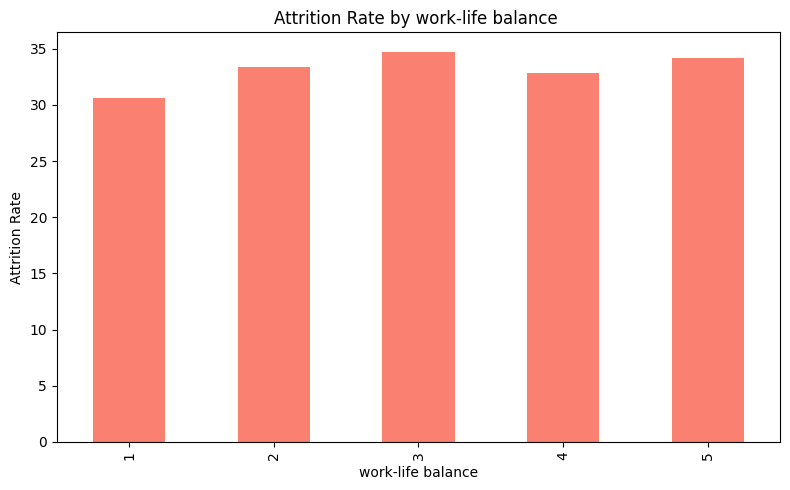

In [180]:
# Compare work-life balance with Attrition Rate
Attrition_by_work_life_balance = merged_data.groupby('WorkLifeBalance')['Attrition'].value_counts(normalize=True).unstack() *100 
print(Attrition_by_work_life_balance.sort_values(by=['Yes'],ascending=False))

Attrition_by_work_life_balance['Yes'].plot(kind='bar', color='salmon', figsize=(8, 5))
plt.title('Attrition Rate by work-life balance ')
plt.xlabel('work-life balance')
plt.ylabel('Attrition Rate')
plt.tight_layout() 
plt.show()

In [181]:
# Analyze work-life balance by marital status
work_life_balance_by_marital_status = merged_data.groupby('MaritalStatus')['WorkLifeBalance'].mean()
print(work_life_balance_by_marital_status.sort_values(ascending=False))

MaritalStatus
Married     3.445337
Single      3.405043
Divorced    3.366208
Name: WorkLifeBalance, dtype: float64


> How does manager rating impact attrition?

In [182]:
# Attrition by Manager Rating
attrition_by_Manager_Rating = (
    merged_data.groupby( 'ManagerRating')['Attrition']
    .value_counts(normalize=True) 
    .unstack() * 100)
# Display the results
print(attrition_by_self_rating.sort_values(by=['Yes'],ascending=False))

Attrition          No        Yes
SelfRating                      
5           66.010078  33.989922
3           66.331878  33.668122
4           66.547406  33.452594


**Education and Training**

> What is the attrition rate by Training Opportunities Taken?

Attrition                          No        Yes
TrainingOpportunitiesTaken                      
1                           65.455288  34.544712
2                           65.683230  34.316770
0                           66.652614  33.347386
3                           69.666667  30.333333


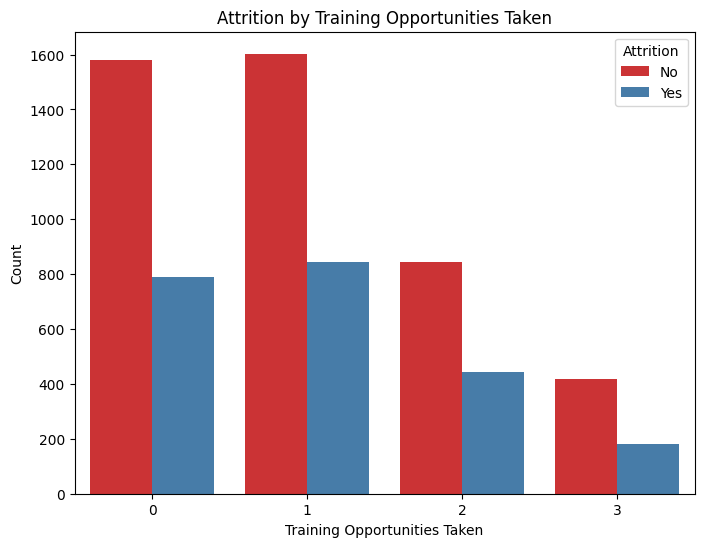

In [183]:
attrition_by_TrainingOpportunities = merged_data.groupby('TrainingOpportunitiesTaken')['Attrition'].value_counts(normalize=True).unstack() * 100
print(attrition_by_TrainingOpportunities.sort_values(by=['Yes'], ascending=False))
plt.figure(figsize=(8, 6))
sns.countplot(x='TrainingOpportunitiesTaken', hue='Attrition', data=merged_data, palette='Set1')
plt.title('Attrition by Training Opportunities Taken')
plt.xlabel('Training Opportunities Taken')
plt.ylabel('Count')
plt.show()

> What is the attrition rate by education level?

In [184]:
attrition_by_education = merged_data.groupby('Education')['Attrition'].value_counts(normalize=True).unstack() * 100
print(attrition_by_education.sort_values(by=['Yes'], ascending=False))

Attrition         No        Yes
Education                      
3          63.971147  36.028853
1          64.642857  35.357143
4          67.423790  32.576210
2          68.763879  31.236121
5          77.251185  22.748815


**correlation between numerical features and attrition.**

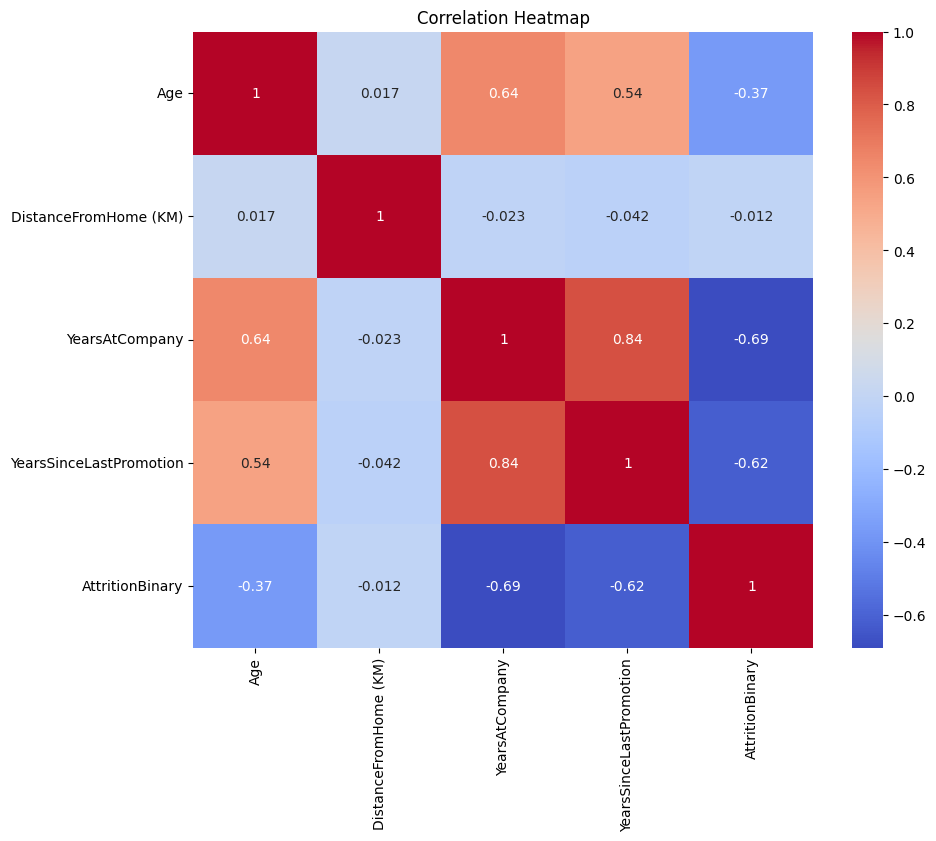

In [185]:
merged_data['AttritionBinary'] = em_data['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
plt.figure(figsize=(10, 8))
correlation_matrix = merged_data[['Age', 'DistanceFromHome (KM)', 'YearsAtCompany', 'TrainingOpportunitiesTaken','Education','YearsSinceLastPromotion', 'AttritionBinary']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

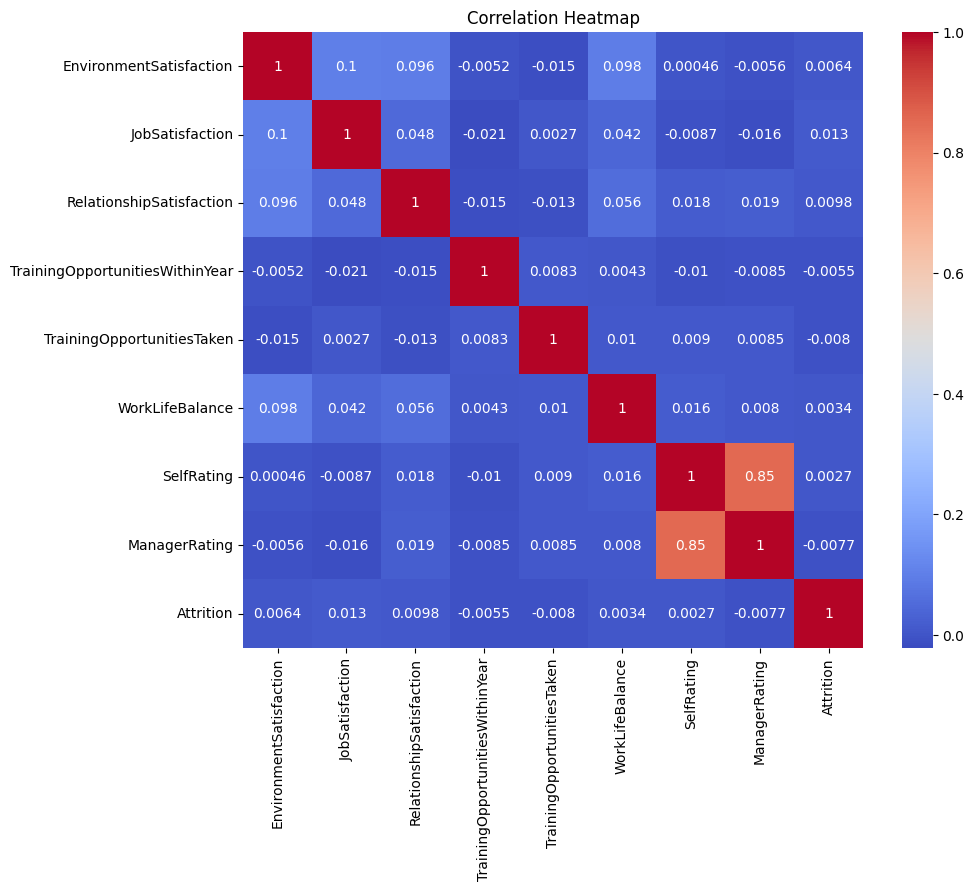

In [186]:
merged_data["Attrition"] = merged_data["Attrition"].map({"No": 0, "Yes": 1})
plt.figure(figsize=(10, 8))
correlation_matrix = merged_data[['EnvironmentSatisfaction', 'JobSatisfaction',
       'RelationshipSatisfaction', 'TrainingOpportunitiesWithinYear',
       'TrainingOpportunitiesTaken', 'WorkLifeBalance', 'SelfRating',
       'ManagerRating','Attrition']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Correlation with Attrition:
 Attrition                            1.000000
OverTime_Yes                         0.305746
MaritalStatus_Single                 0.234513
JobRole_Sales Representative         0.184627
JobRole_Data Scientist               0.108765
Department_Sales                     0.104592
JobRole_Recruiter                    0.076575
JobRole_Sales Executive              0.022901
JobSatisfaction                      0.013237
RelationshipSatisfaction             0.009758
EnvironmentSatisfaction              0.006418
WorkLifeBalance                      0.003429
SelfRating                           0.002727
JobRole_Software Engineer           -0.003612
TrainingOpportunitiesWithinYear     -0.005505
ManagerRating                       -0.007654
TrainingOpportunitiesTaken          -0.007995
JobRole_HR Executive                -0.023702
JobRole_HR Manager                  -0.034859
JobRole_HR Business Partner         -0.041817
JobRole_Manager                     -0.062169
Busin

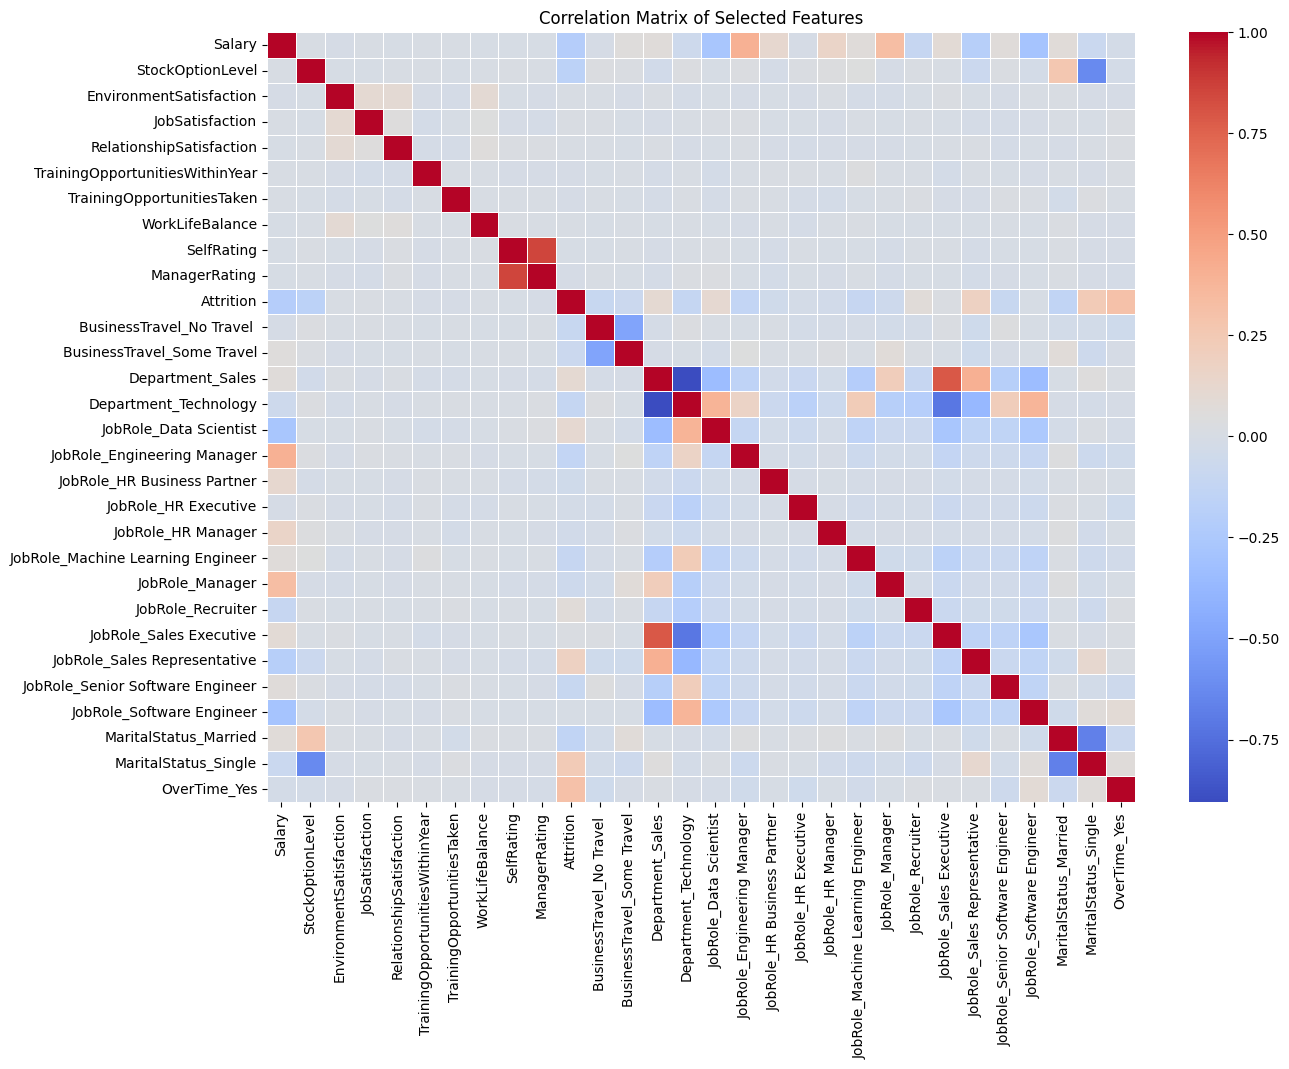

In [61]:
merged_data["Attrition"] = merged_data["Attrition"].map({"No": 0, "Yes": 1})
# Select the columns you're interested in
cols = ['BusinessTravel', 'Department', 'JobRole', 'MaritalStatus',
        'Salary', 'StockOptionLevel', 'OverTime', 'EnvironmentSatisfaction',
        'JobSatisfaction', 'RelationshipSatisfaction', 'TrainingOpportunitiesWithinYear',
        'TrainingOpportunitiesTaken', 'WorkLifeBalance', 'SelfRating',
        'ManagerRating', 'Attrition']

# Subset your dataframe
df_subset = merged_data[cols].copy()

# Encode categorical variables
df_encoded = pd.get_dummies(df_subset, drop_first=True)

# Compute correlation matrix
correlation_matrix = df_encoded.corr()

# Optionally, focus on how things correlate with Attrition:
attrition_corr = correlation_matrix["Attrition"].sort_values(ascending=False)
print("Correlation with Attrition:\n", attrition_corr)

# Plot heatmap for all correlations
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Selected Features")
plt.show()
